# Simulation study evaluation plots

Reads the tidy outputs of `extract_trans_eval.R` (`trans_eval_long.csv`) and
`extract_cis_mse.py` (`cis_eval.csv`) -- see `docs/SIMULATION_STUDY_PLAN.md` §8.

**Assumptions made where the plot spec was ambiguous** (isolated to the helper
functions below -- check against real output and adjust if wrong):
- TPR/prop-additive-hill plots: "facets for the different y_ntc values" + "additionally
  facetted by X/Y" is implemented as nested `facet_grid` rows (e.g.
  `cells_per_gene + y_ntc_log2 ~ n_guides`), not a separate figure per y_ntc.
- TPR's continuous x-axis (`prop_log2FC_observed`) is binned (8 equal-width bins, 0-1)
  to compute a rate per bin; `full_log2FC_true` is used directly as discrete color
  (only 4 grid values, no binning needed).
- "Prop. additive_hill fit" is built with both facet schemes, mirroring the paired
  FPR/TPR plots.
- **3a (n) and 3d (full log2FC)** are boxplots: x = binned `prop_log2FC_observed`,
  fill = the true value (discrete grid), box = distribution of the estimate, black "x"
  markers = the true value at the matching dodge position. 3d is restricted to
  single_hill-truth features only (a binned-proportion x-axis isn't meaningful for
  null-truth rows, which have no `prop_log2FC_observed`) -- this drops null features
  from 3d, unlike the original scatter version.
- **3c (y_ntc)** is a boxplot: x = true `y_ntc_log2` (already a 4-value discrete grid),
  fill = true `o_y_log2` (already discrete, 2 values), same "x" true-value marker
  convention. Applies to all features (both null and single_hill truth).
- **3b (EC50)** stays a scatter plot, now produced with **two fill variants** per facet
  scheme: the original `prop_log2FC_observed`, and an alternate `guide_log2_range`
  (`log2(x_max) - log2(x_min)` of the guides' achieved cis-expression range for that
  scenario/replicate -- a scenario-level quantity, constant across features within one
  scenario/replicate).
- **FPR bars (1a/1b)** now have the group's `n` (feature count) printed above each bar,
  to distinguish "genuinely FPR=0" from "no data for this grid cell" -- both look like
  an empty panel otherwise.


In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
})

Warning message:
“package ‘data.table’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”


In [2]:
# --- Config -- edit these paths ---
basedir <- '/cfs/klemming/projects/snic/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/Simulations/'
trans_eval_path <- paste0(basedir, "trans_eval_long.csv")
cis_eval_path <- paste0(basedir, "cis_eval.csv")
outdir <- paste0(basedir, "./eval_plots")
dir.create(outdir, showWarnings = FALSE, recursive = TRUE)

In [3]:
my_plot_func <- function(p, width=5, height=4) {
    options(repr.plot.width=width, repr.plot.height=height)
    library(png)
    library(grid)
    ggsave("p_tmp.png", plot = p, width = width, height = height)
    img <- readPNG("p_tmp.png")
    grid.raster(img)
    grid.newpage()
}

save_plot <- function(p, name, width = 10, height = 8) {
  # Displays inline (IRkernel auto-prints the last expression of a cell, but not
  # inside a loop/function call, so this prints explicitly) and saves to PDF.
  my_plot_func(p, width, height)
  path <- file.path(outdir, paste0(name, ".pdf"))
  ggsave(path, p, width = width, height = height, limitsize = FALSE)
  invisible(p)
}

In [4]:
trans_eval <- fread(trans_eval_path)
cis_eval <- fread(cis_eval_path)

# Shared derived columns
trans_eval[, y_ntc_log2_fit := log2(y_ntc)]
trans_eval[, prop_bin := cut(prop_log2FC_observed, breaks = seq(0, 1, by = 0.125),
                              include.lowest = TRUE)]
trans_eval[, guide_range_bin := cut(guide_log2_range, breaks = 6, include.lowest = TRUE)]
guide_shapes <- sort(unique(trans_eval$guide_shape))
cat(sprintf("Loaded %d trans_eval rows, %d cis_eval rows, guide_shapes = %s\n",
            nrow(trans_eval), nrow(cis_eval), paste(guide_shapes, collapse = ", ")))

Loaded 1140552 trans_eval rows, 720 cis_eval rows


## 1. False positive rate

FPR per `(y_ntc_log2, o_y_log2, <facet vars>)` = fraction of `no_effect`-truth features called positive, pooling across matching scenarios/replicates. Bar labels show `n` (feature count in that group) -- a bar that's absent (not just short) means zero features fell in that grid cell, not FPR=0.

In [5]:
fpr_data <- trans_eval[effect_type == "no_effect"]

make_fpr_plot <- function(dt, facet_rows, facet_cols, title_suffix) {
  agg <- dt[, .(FPR = mean(is_positive, na.rm = TRUE), n = .N),
            by = c("y_ntc_log2", "o_y_log2", facet_rows, facet_cols)]
  ggplot(agg, aes(x = factor(y_ntc_log2), y = FPR, fill = factor(o_y_log2))) +
    geom_col(position = position_dodge(width = 0.8), width = 0.7) +
    geom_point(aes(size = n), position = position_dodge(width = 0.8),
               color = "black", alpha = 0.7) +
    geom_hline(yintercept = 0.05, linetype = "dashed", color = "red") +
    facet_grid(reformulate(facet_cols, paste(facet_rows, collapse = "+"))) +
    labs(x = "y_ntc (log2)", y = "False positive rate", fill = "y overdispersion (log2)",
         size = "n features",
         title = paste("FPR (point size = n features) --", title_suffix)) +
    theme_bw()
}

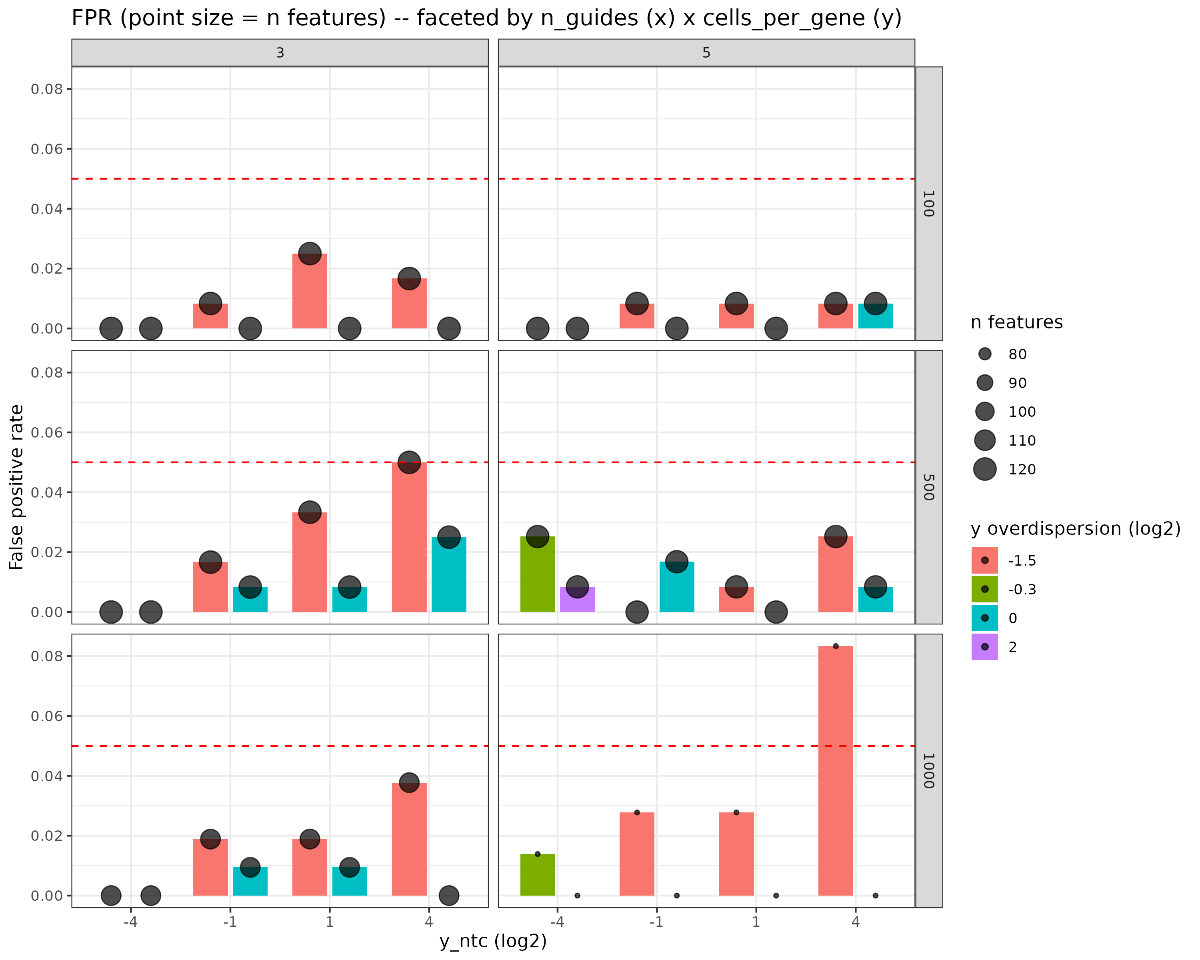

In [6]:
for (shape in guide_shapes) {
  save_plot(make_fpr_plot(fpr_data[guide_shape == shape], "cells_per_gene", "n_guides",
                           paste0("faceted by n_guides (x) x cells_per_gene (y), shape=", shape)),
            paste0("1a_fpr_by_guides_cells_", shape))
}

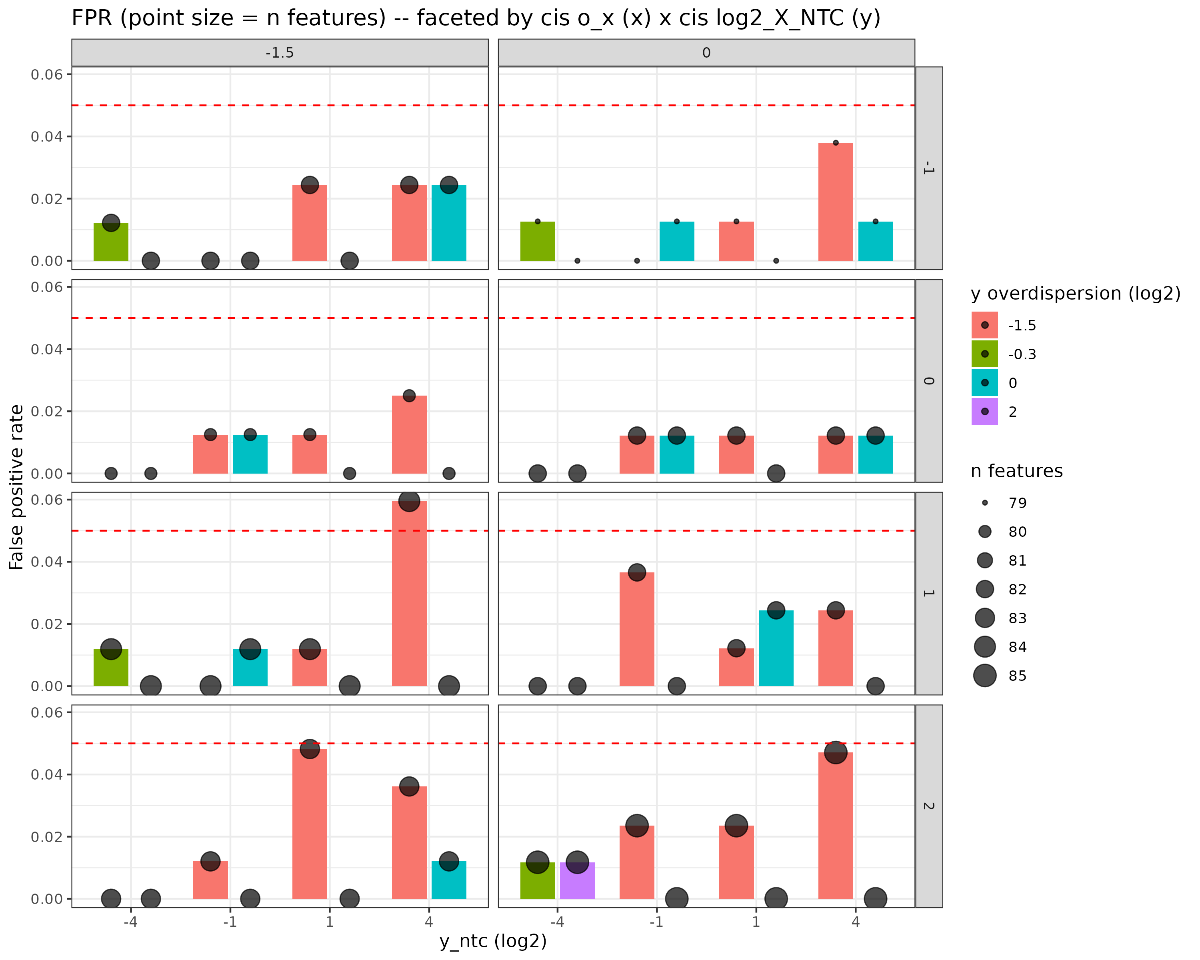

In [7]:
for (shape in guide_shapes) {
  save_plot(make_fpr_plot(fpr_data[guide_shape == shape], "log2_X_NTC", "log2_o_x",
                           paste0("faceted by cis o_x (x) x cis log2_X_NTC (y), shape=", shape)),
            paste0("1b_fpr_by_cis_ox_xntc_", shape))
}

## 2. True positive rate (+ prop. additive_hill fit)

Restricted to single_hill-truth features whose fit came out `single_hill` or `not_dependent` ("flat") -- excludes `additive_hill` fits, reported separately below as their own proportion.

In [8]:
tpr_base <- trans_eval[effect_type == "single_hill" &
                          fit_type %in% c("single_hill", "not_dependent")]

make_tpr_plot <- function(dt, facet_rows, facet_cols, title_suffix) {
  agg <- dt[!is.na(prop_bin), .(TPR = mean(is_positive, na.rm = TRUE), n = .N),
            by = c("prop_bin", "full_log2FC_true", "y_ntc_log2", facet_rows, facet_cols)]
  ggplot(agg, aes(x = prop_bin, y = TPR, color = factor(full_log2FC_true))) +
    geom_point(aes(size = n), alpha = 0.7) +
    geom_line(aes(group = factor(full_log2FC_true))) +
    facet_grid(reformulate(facet_cols, paste(c(facet_rows, "y_ntc_log2"), collapse = "+"))) +
    labs(x = "Proportion of full log2FC observed (binned)", y = "True positive rate",
         color = "True full log2FC", size = "n features",
         title = paste("TPR (single_hill/flat fits only) --", title_suffix)) +
    theme_bw() + theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

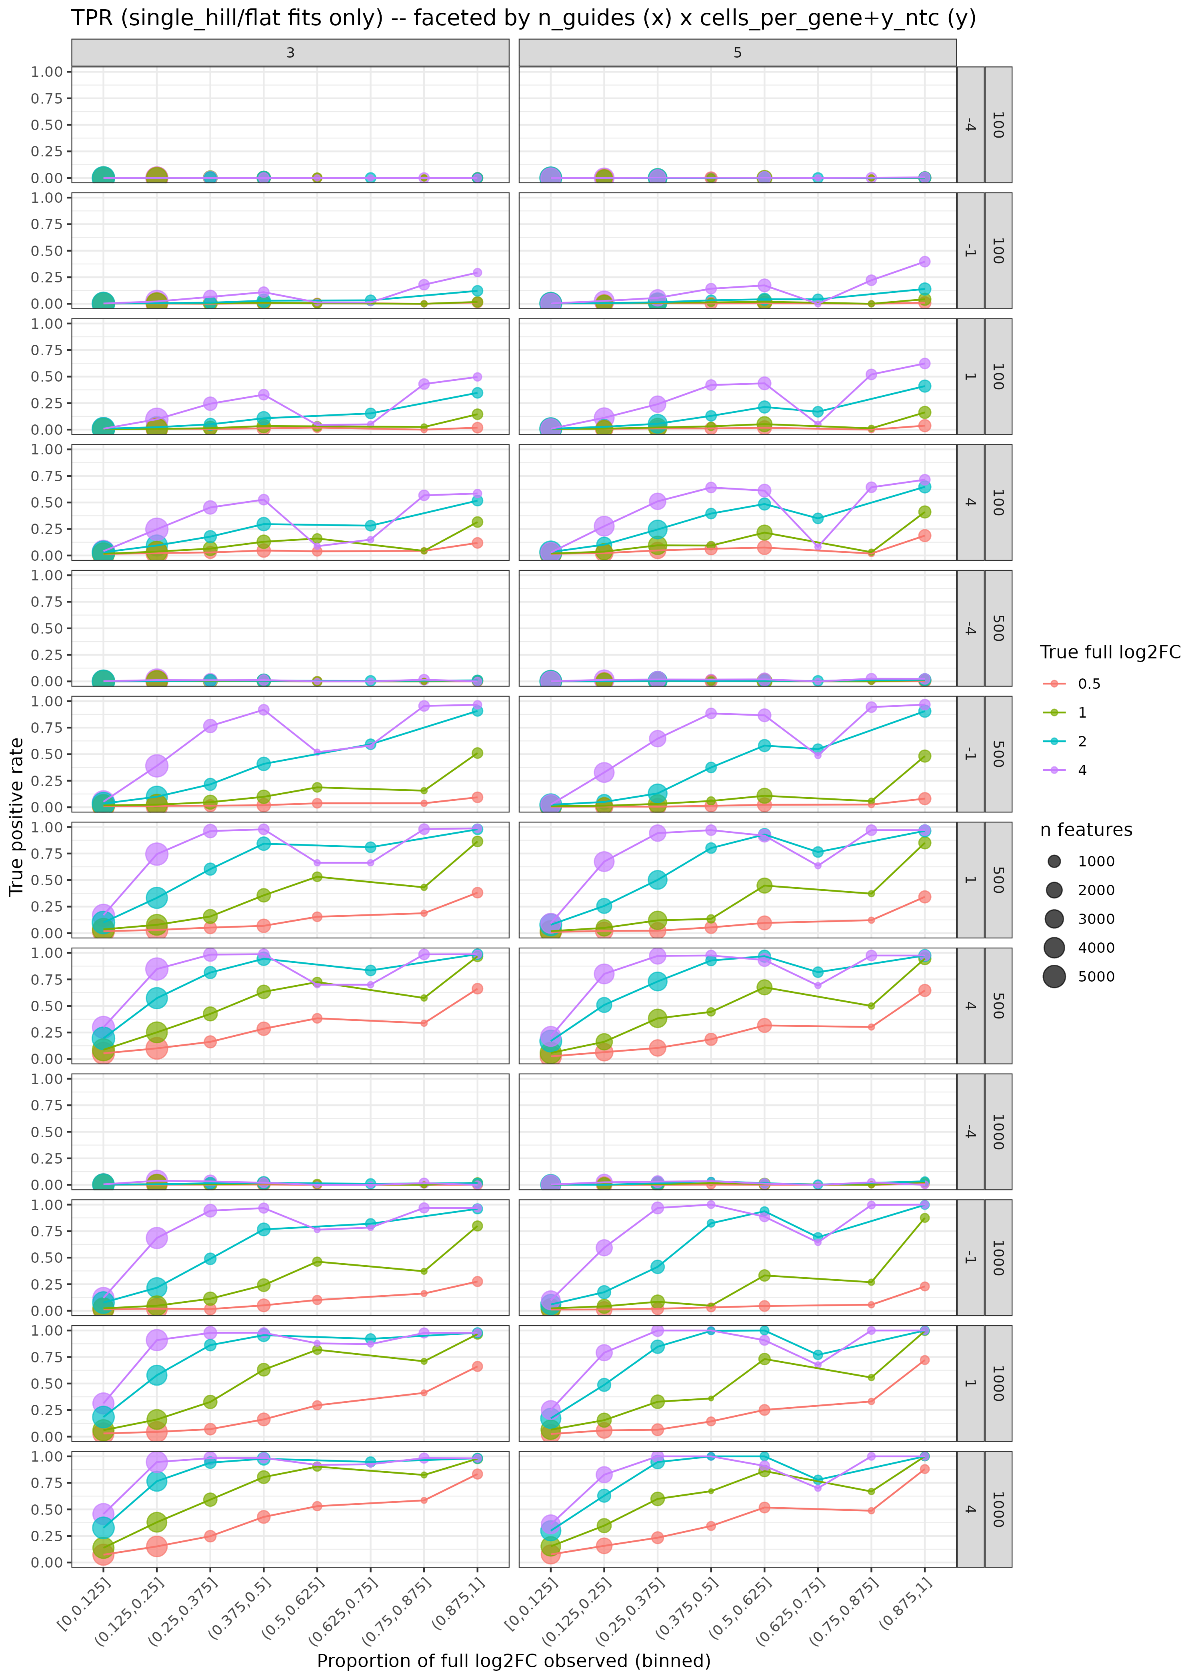

In [9]:
for (shape in guide_shapes) {
  save_plot(make_tpr_plot(tpr_base[guide_shape == shape], "cells_per_gene", "n_guides",
                           paste0("faceted by n_guides (x) x cells_per_gene+y_ntc (y), shape=", shape)),
            paste0("2a_tpr_by_guides_cells_", shape), height = 14)
}

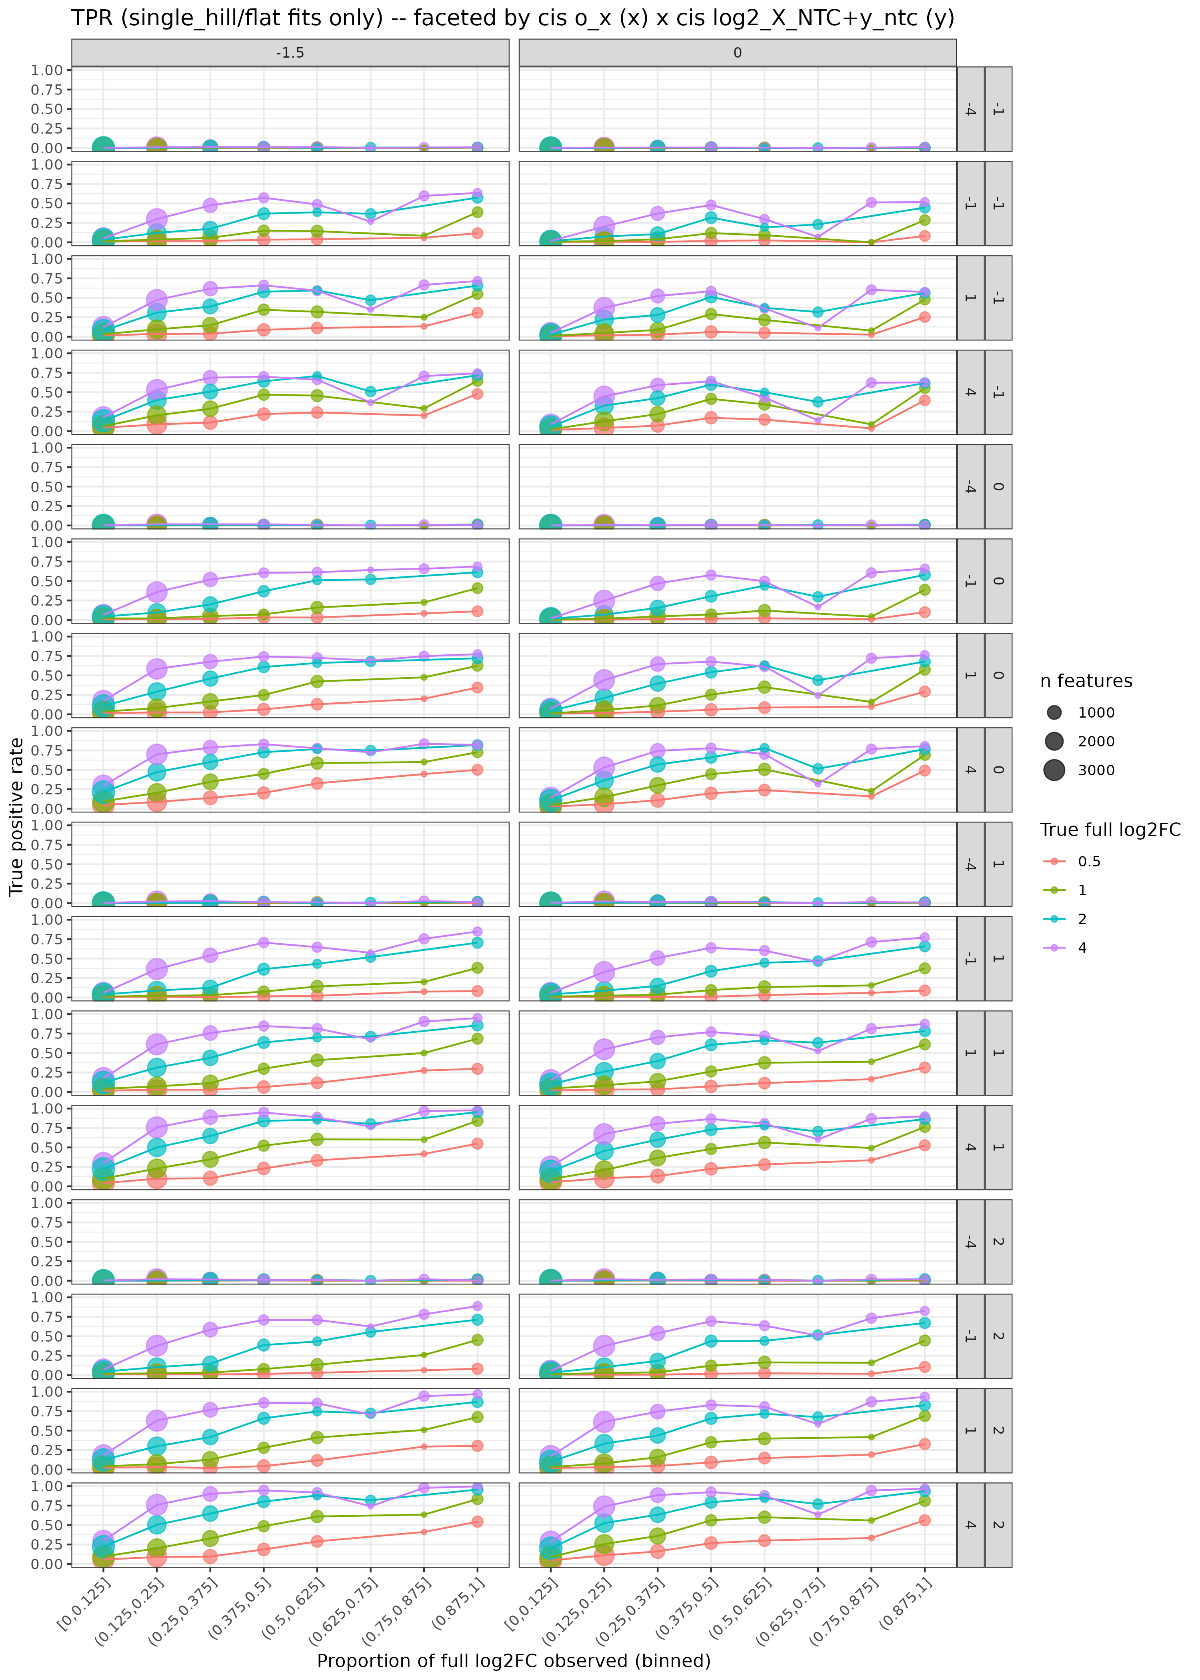

In [10]:
for (shape in guide_shapes) {
  save_plot(make_tpr_plot(tpr_base[guide_shape == shape], "log2_X_NTC", "log2_o_x",
                           paste0("faceted by cis o_x (x) x cis log2_X_NTC+y_ntc (y), shape=", shape)),
            paste0("2b_tpr_by_cis_ox_xntc_", shape), height = 14)
}

In [11]:
prop_add_base <- trans_eval[effect_type == "single_hill"]
prop_add_base[, is_additive := fit_type == "additive_hill"]

make_prop_additive_plot <- function(dt, facet_rows, facet_cols, title_suffix) {
  agg <- dt[!is.na(prop_bin), .(prop_additive = mean(is_additive, na.rm = TRUE), n = .N),
            by = c("prop_bin", "full_log2FC_true", "y_ntc_log2", facet_rows, facet_cols)]
  ggplot(agg, aes(x = prop_bin, y = prop_additive, color = factor(full_log2FC_true))) +
    geom_point(aes(size = n), alpha = 0.7) +
    geom_line(aes(group = factor(full_log2FC_true))) +
    facet_grid(reformulate(facet_cols, paste(c(facet_rows, "y_ntc_log2"), collapse = "+"))) +
    labs(x = "Proportion of full log2FC observed (binned)", y = "Proportion fit as additive_hill",
         color = "True full log2FC", size = "n features",
         title = paste("Prop. additive_hill fit (single_hill truth) --", title_suffix)) +
    theme_bw() + theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

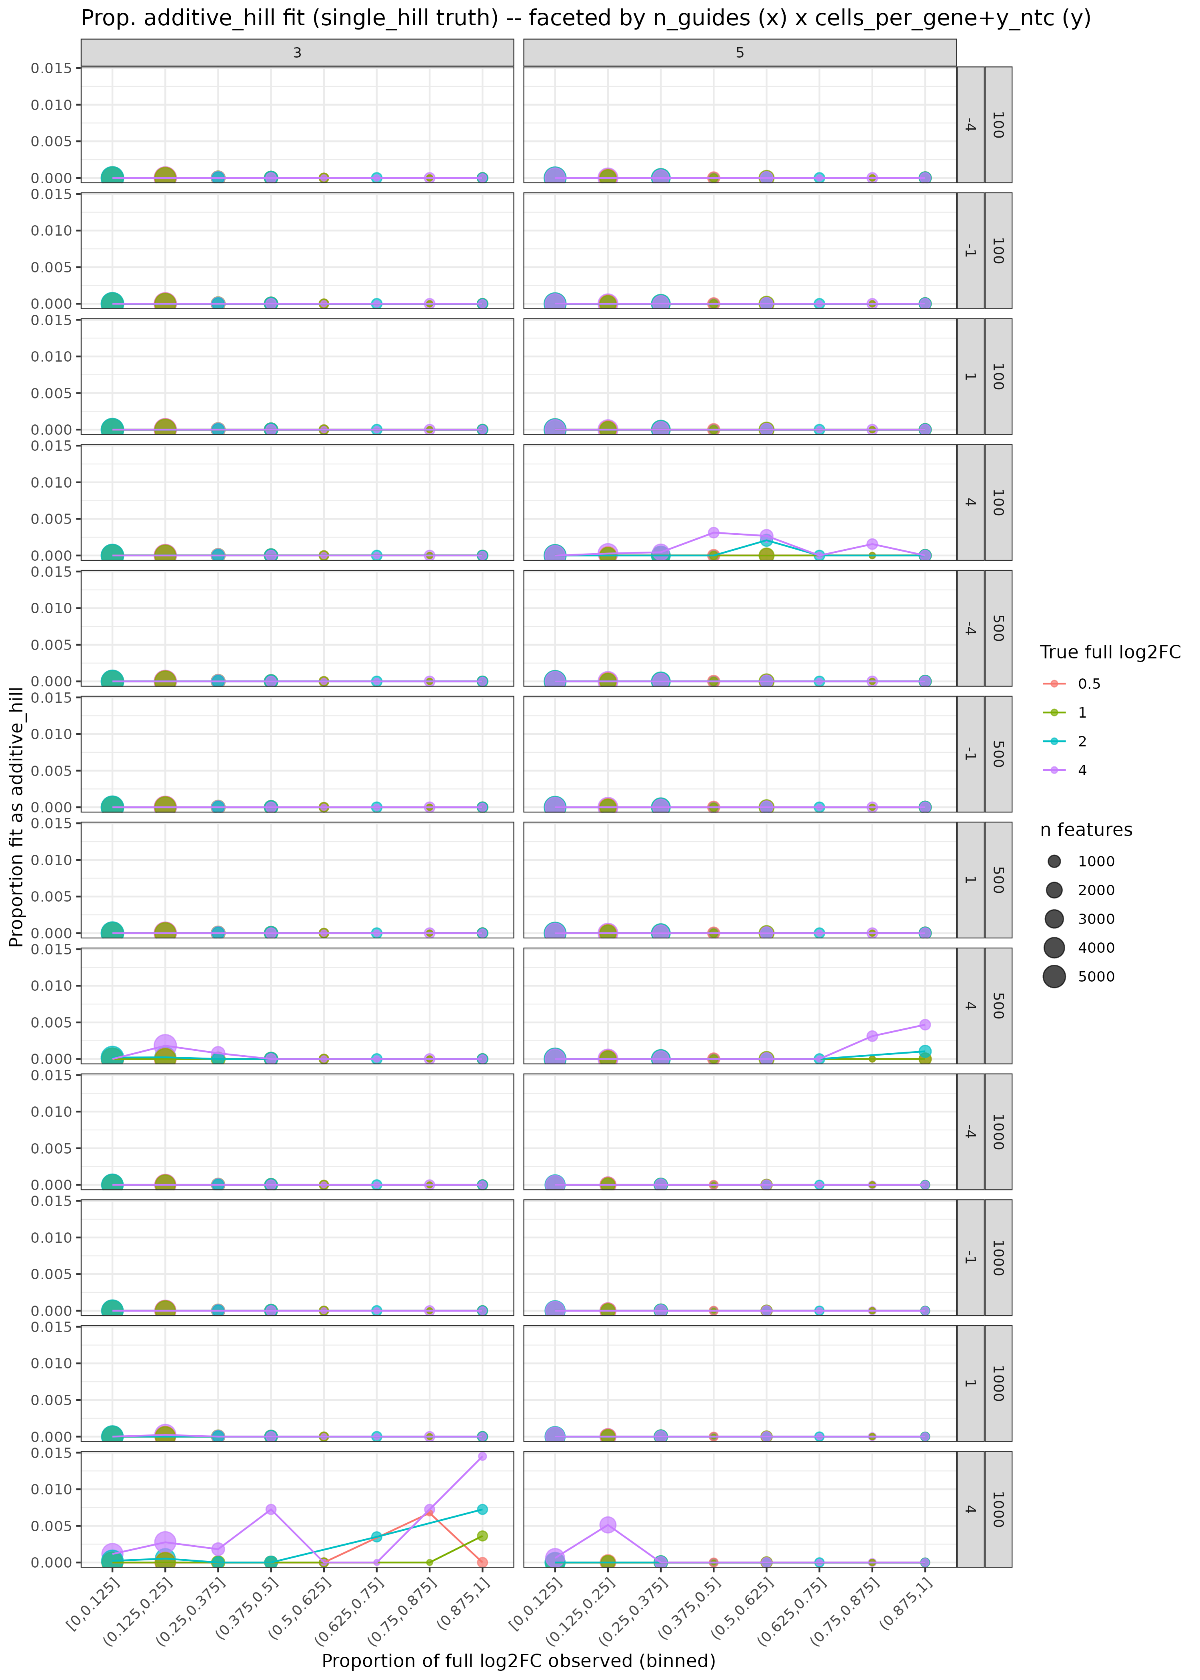

In [12]:
for (shape in guide_shapes) {
  save_plot(make_prop_additive_plot(prop_add_base[guide_shape == shape], "cells_per_gene", "n_guides",
                                     paste0("faceted by n_guides (x) x cells_per_gene+y_ntc (y), shape=", shape)),
            paste0("2c_prop_additive_by_guides_cells_", shape), height = 14)
}

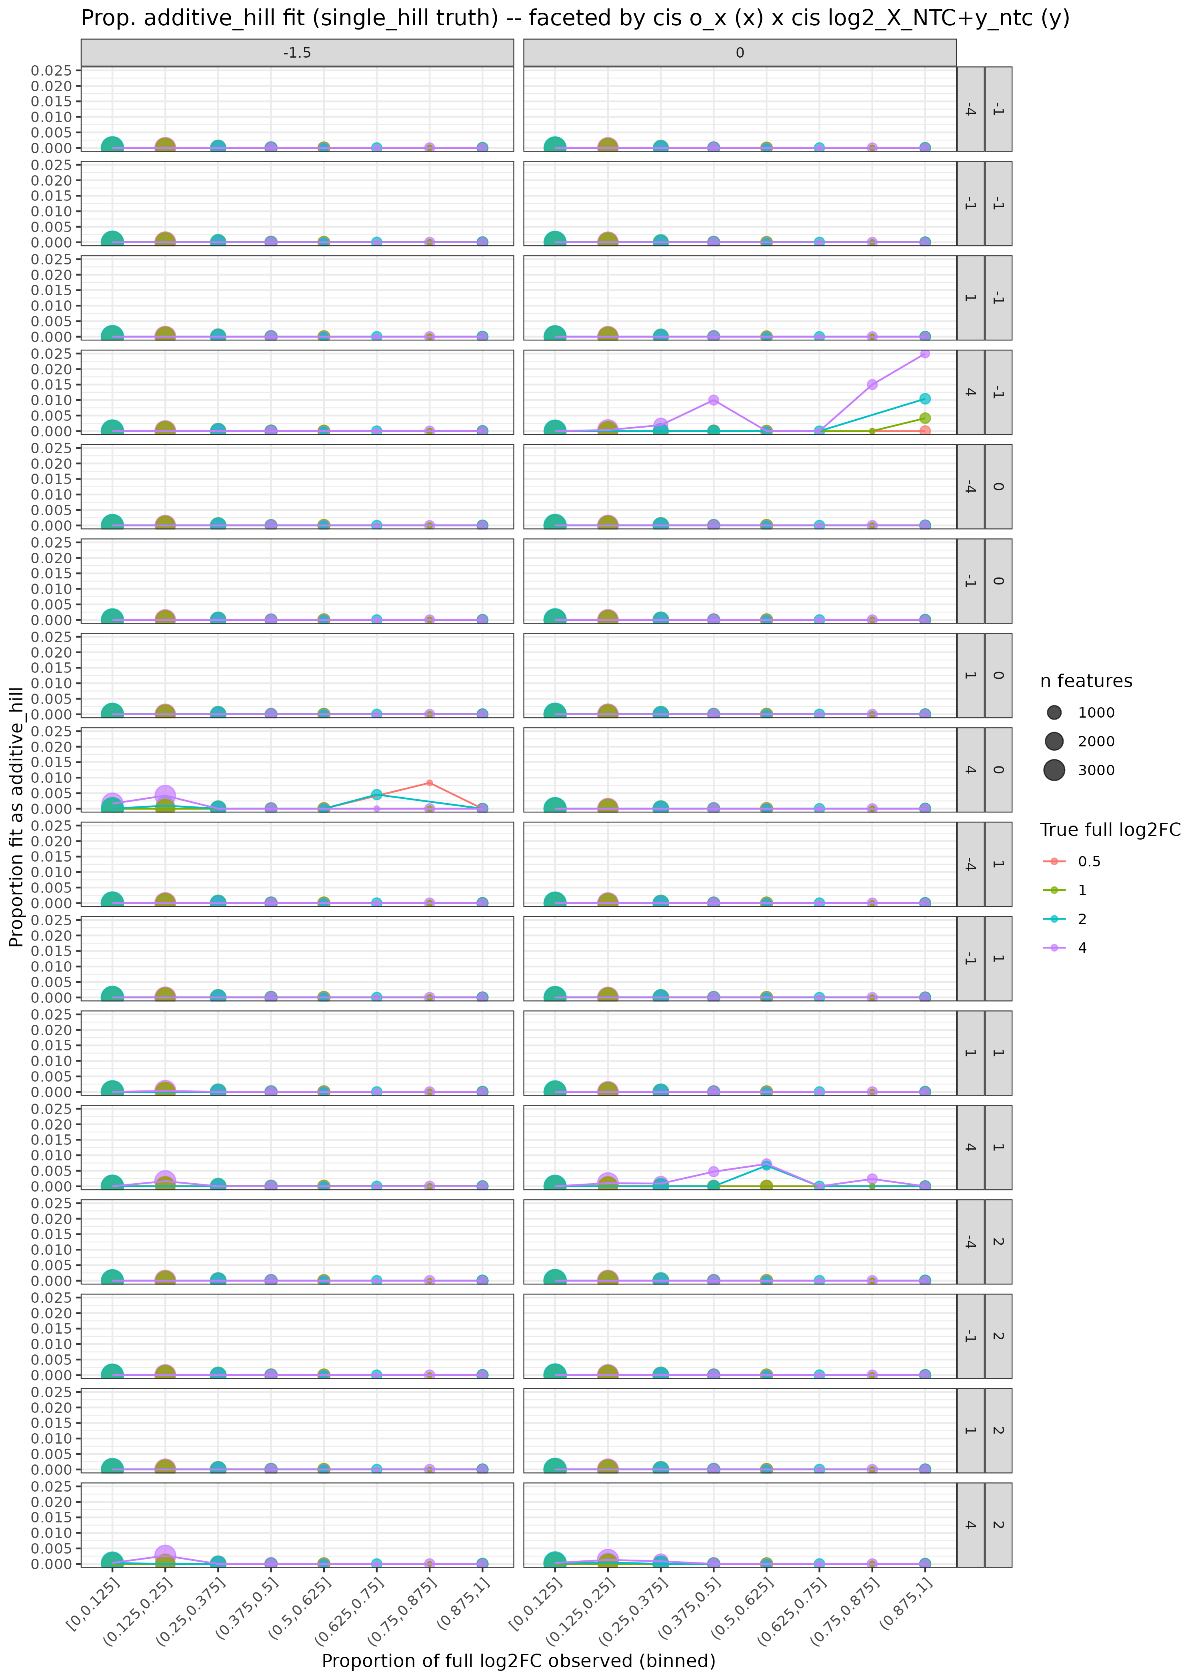

In [13]:
for (shape in guide_shapes) {
  save_plot(make_prop_additive_plot(prop_add_base[guide_shape == shape], "log2_X_NTC", "log2_o_x",
                                     paste0("faceted by cis o_x (x) x cis log2_X_NTC+y_ntc (y), shape=", shape)),
            paste0("2d_prop_additive_by_cis_ox_xntc_", shape), height = 14)
}

## 3. Estimated vs true

3a/3b/3d are restricted to `classification == "single_positive"` (ground truth is
single_hill AND the fit was recovered as a clean single positive-direction Hill curve)
-- excludes single_negative, additive, and non-monotonic fits, since those don't have
a single well-defined recovered curve to plot against a single-Hill truth.

All plots in this section are also separated by `guide_shape` (even/gap/small), one
figure per shape.

### 3a. Hill exponent `n`

Boxplot of the estimated `n` within each binned `prop_log2FC_observed` x true-n group;
black × marks the true value at the matching dodge position.

In [14]:
sh_active_n <- trans_eval[effect_type == "single_hill" & classification == "single_positive" &
                             !is.na(estimated_n) & !is.na(prop_bin)]

make_n_boxplot <- function(dt, facet_rows, facet_cols, title_suffix) {
  ggplot(dt, aes(x = prop_bin, y = estimated_n, fill = factor(n_true))) +
    geom_boxplot(outlier.size = 0.5, position = position_dodge(width = 0.8)) +
    geom_point(aes(y = n_true), shape = 4, position = position_dodge(width = 0.8),
               color = "black", size = 1.5) +
    facet_grid(reformulate(facet_cols, facet_rows)) +
    labs(x = "Prop. full log2FC observed (binned)", y = "Estimated n", fill = "True n",
         title = paste("n estimated vs true --", title_suffix)) +
    theme_bw() + theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

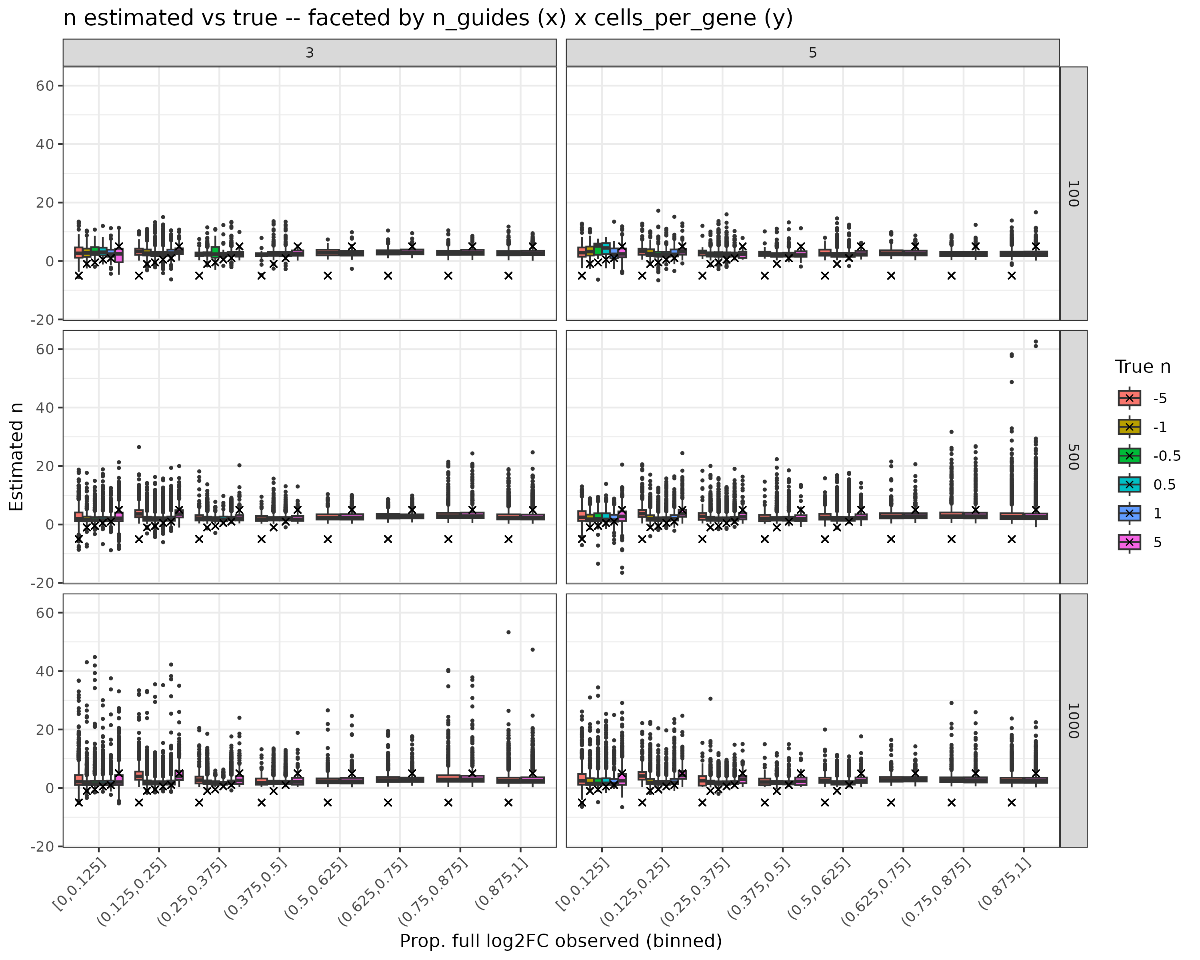

In [15]:
for (shape in guide_shapes) {
  save_plot(make_n_boxplot(sh_active_n[guide_shape == shape], "cells_per_gene", "n_guides",
                            paste0("faceted by n_guides (x) x cells_per_gene (y), shape=", shape)),
            paste0("3a_n_est_vs_true_guides_cells_", shape))
}

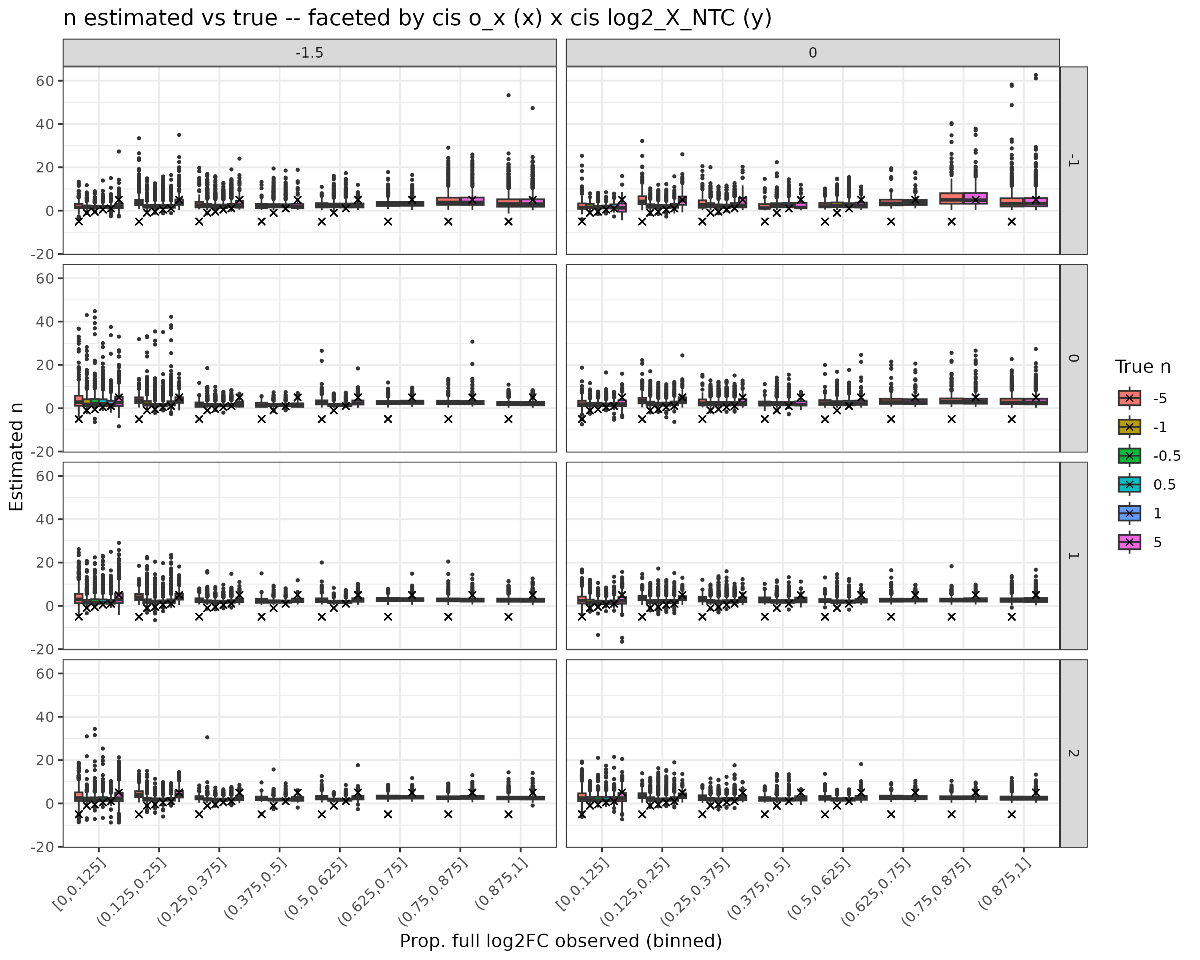

In [16]:
for (shape in guide_shapes) {
  save_plot(make_n_boxplot(sh_active_n[guide_shape == shape], "log2_X_NTC", "log2_o_x",
                            paste0("faceted by cis o_x (x) x cis log2_X_NTC (y), shape=", shape)),
            paste0("3a_n_est_vs_true_cis_ox_xntc_", shape))
}

### 3b. EC50 (log2FC)

Boxplot, same convention as 3a/3d. Two x-axis variants (each binned): the original
`prop_log2FC_observed`, and an alternate `guide_log2_range` (scenario-level guide
dynamic range).

In [17]:
sh_active_k <- trans_eval[effect_type == "single_hill" & classification == "single_positive" &
                             !is.na(estimated_K_log2FC)]

make_ec50_boxplot <- function(dt, x_col, x_lab, facet_rows, facet_cols, title_suffix) {
  dt <- dt[!is.na(get(x_col))]
  ggplot(dt, aes(x = .data[[x_col]], y = estimated_K_log2FC, fill = factor(K_log2FC_true))) +
    geom_boxplot(outlier.size = 0.5, position = position_dodge(width = 0.8)) +
    geom_point(aes(y = K_log2FC_true), shape = 4, position = position_dodge(width = 0.8),
               color = "black", size = 1.5) +
    facet_grid(reformulate(facet_cols, facet_rows)) +
    labs(x = x_lab, y = "Estimated EC50 (log2FC)", fill = "True EC50 (log2FC)",
         title = paste("EC50 estimated vs true --", title_suffix)) +
    theme_bw() + theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

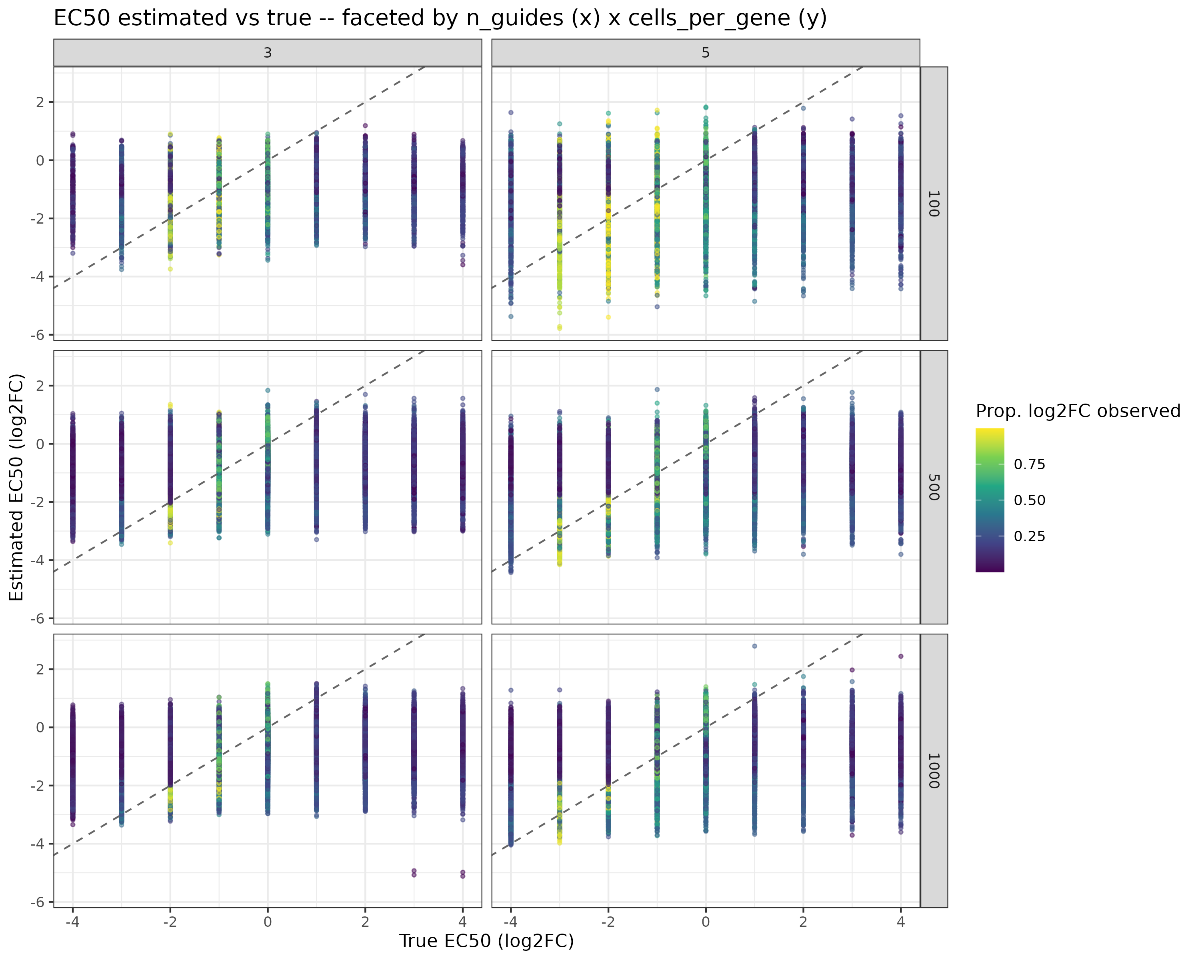

In [18]:
for (shape in guide_shapes) {
  save_plot(make_ec50_boxplot(sh_active_k[guide_shape == shape], "prop_bin",
                               "Prop. log2FC observed (binned)",
                               "cells_per_gene", "n_guides",
                               paste0("faceted by n_guides (x) x cells_per_gene (y), shape=", shape)),
            paste0("3b_EC50_est_vs_true_guides_cells_propobs_", shape))
}

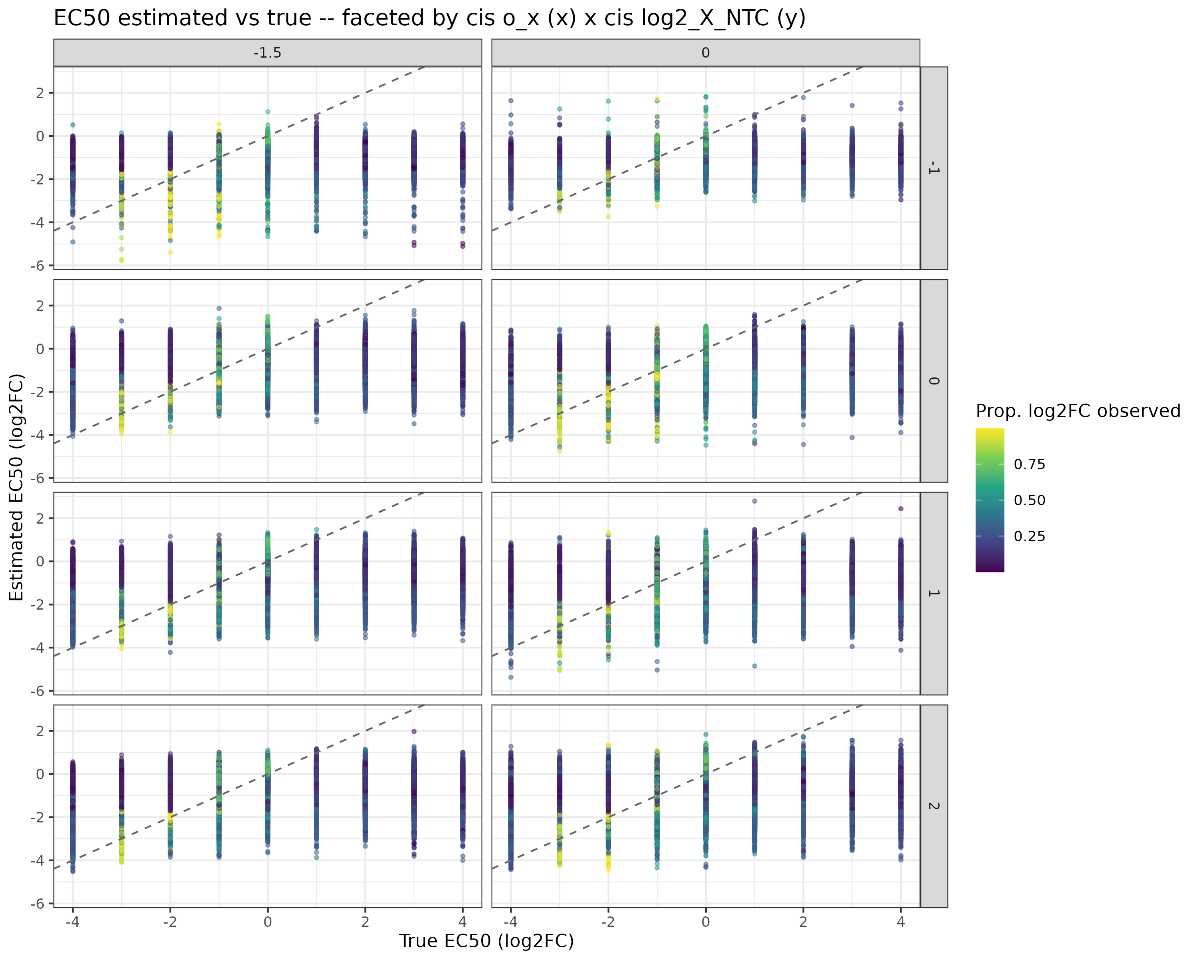

In [19]:
for (shape in guide_shapes) {
  save_plot(make_ec50_boxplot(sh_active_k[guide_shape == shape], "prop_bin",
                               "Prop. log2FC observed (binned)",
                               "log2_X_NTC", "log2_o_x",
                               paste0("faceted by cis o_x (x) x cis log2_X_NTC (y), shape=", shape)),
            paste0("3b_EC50_est_vs_true_cis_ox_xntc_propobs_", shape))
}

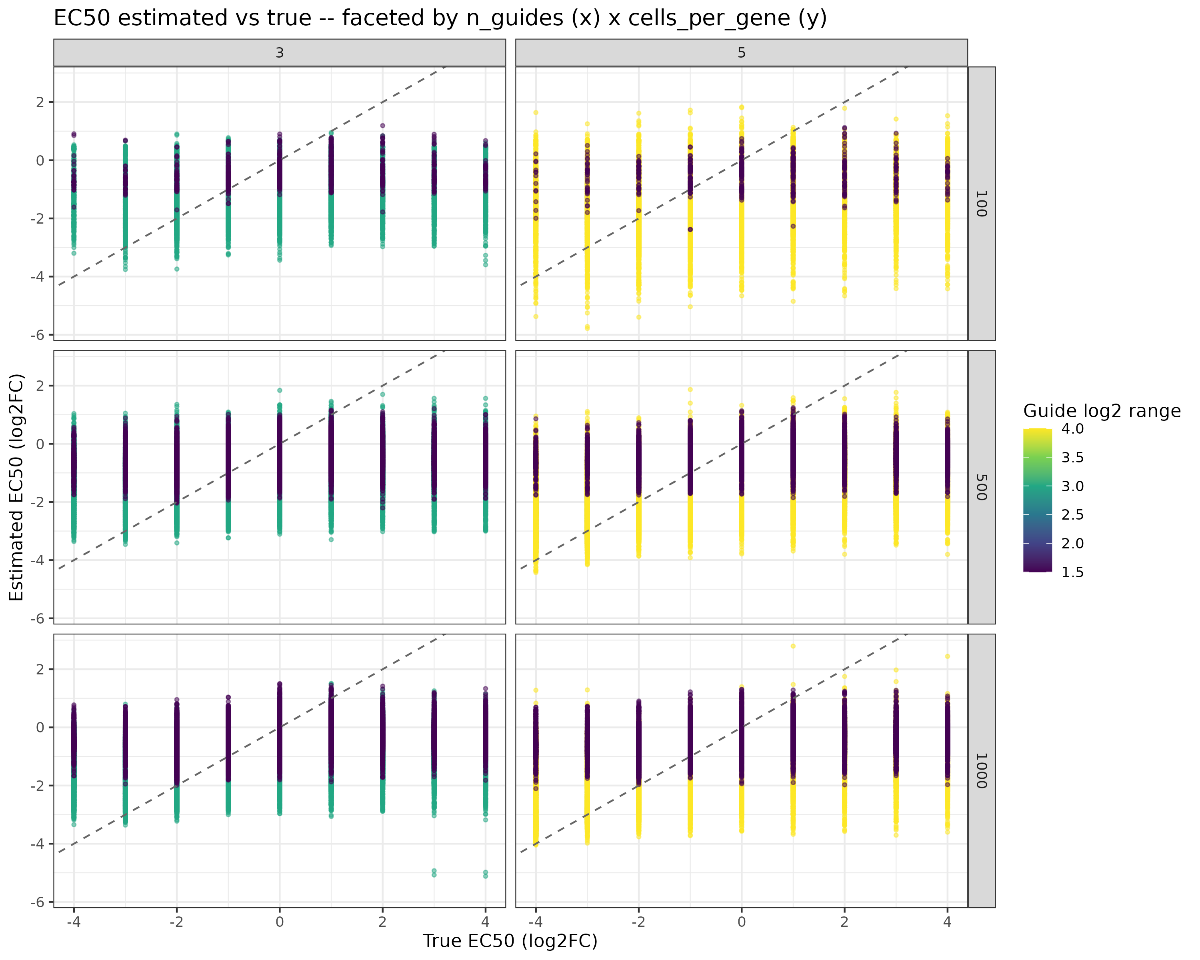

In [20]:
for (shape in guide_shapes) {
  save_plot(make_ec50_boxplot(sh_active_k[guide_shape == shape], "guide_range_bin",
                               "Guide log2 range (binned)",
                               "cells_per_gene", "n_guides",
                               paste0("faceted by n_guides (x) x cells_per_gene (y), shape=", shape)),
            paste0("3b_EC50_est_vs_true_guides_cells_guiderange_", shape))
}

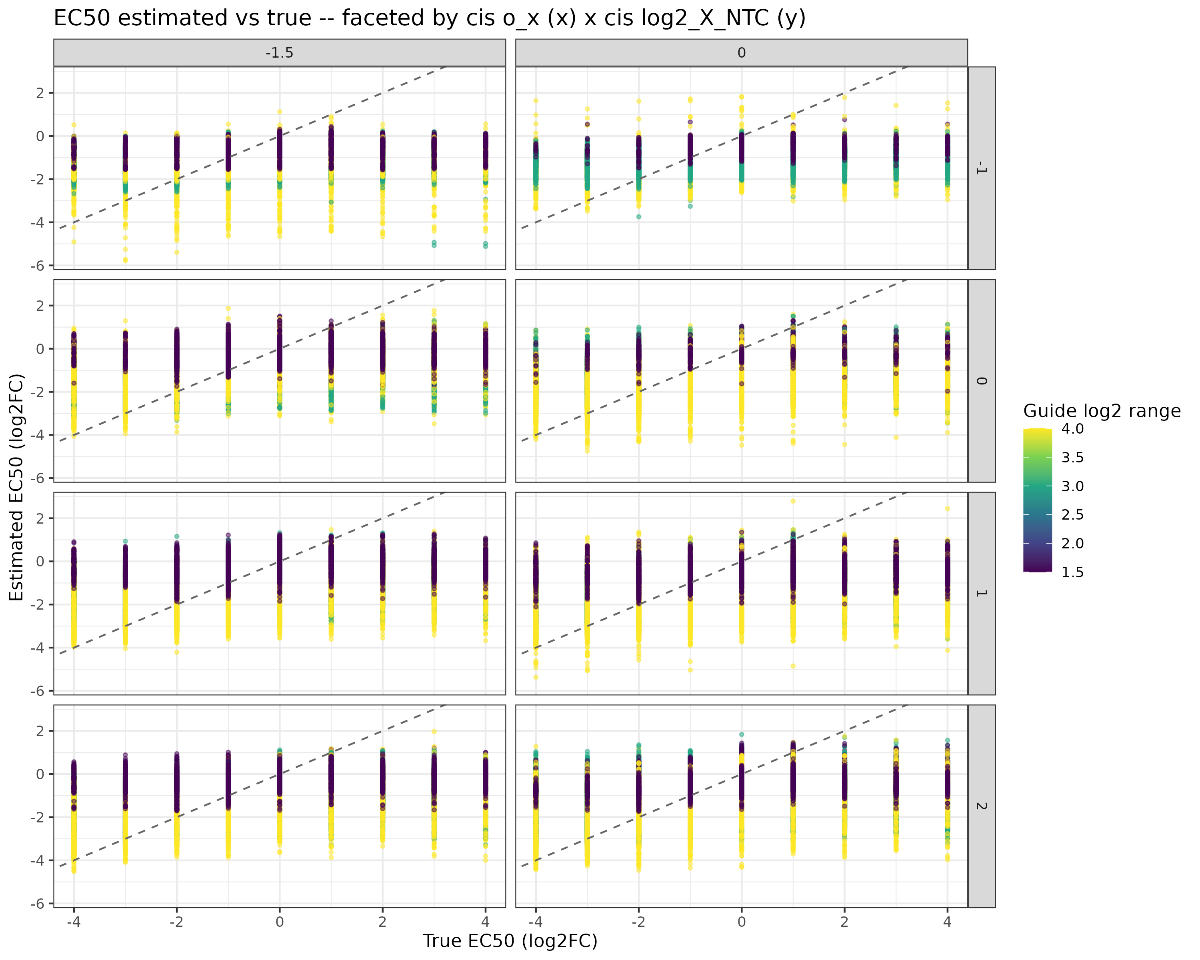

In [21]:
for (shape in guide_shapes) {
  save_plot(make_ec50_boxplot(sh_active_k[guide_shape == shape], "guide_range_bin",
                               "Guide log2 range (binned)",
                               "log2_X_NTC", "log2_o_x",
                               paste0("faceted by cis o_x (x) x cis log2_X_NTC (y), shape=", shape)),
            paste0("3b_EC50_est_vs_true_cis_ox_xntc_guiderange_", shape))
}

### 3c. `y_ntc`

Boxplot, since both x (true `y_ntc_log2`) and fill (true `o_y_log2`) are already discrete grids. Black × marks the true value. Applies to all features (null and single_hill truth).

In [22]:
make_yntc_boxplot <- function(dt, facet_rows, facet_cols, title_suffix) {
  ggplot(dt[!is.na(y_ntc_log2_fit)], aes(x = factor(y_ntc_log2), y = y_ntc_log2_fit,
                                          fill = factor(o_y_log2))) +
    geom_boxplot(outlier.size = 0.5, position = position_dodge(width = 0.8)) +
    geom_point(aes(y = y_ntc_log2), shape = 4, position = position_dodge(width = 0.8),
               color = "black", size = 1.5) +
    facet_grid(reformulate(facet_cols, facet_rows)) +
    labs(x = "True y_ntc (log2)", y = "Estimated y_ntc (log2)",
         fill = "True y overdispersion (log2)",
         title = paste("y_ntc estimated vs true --", title_suffix)) +
    theme_bw()
}

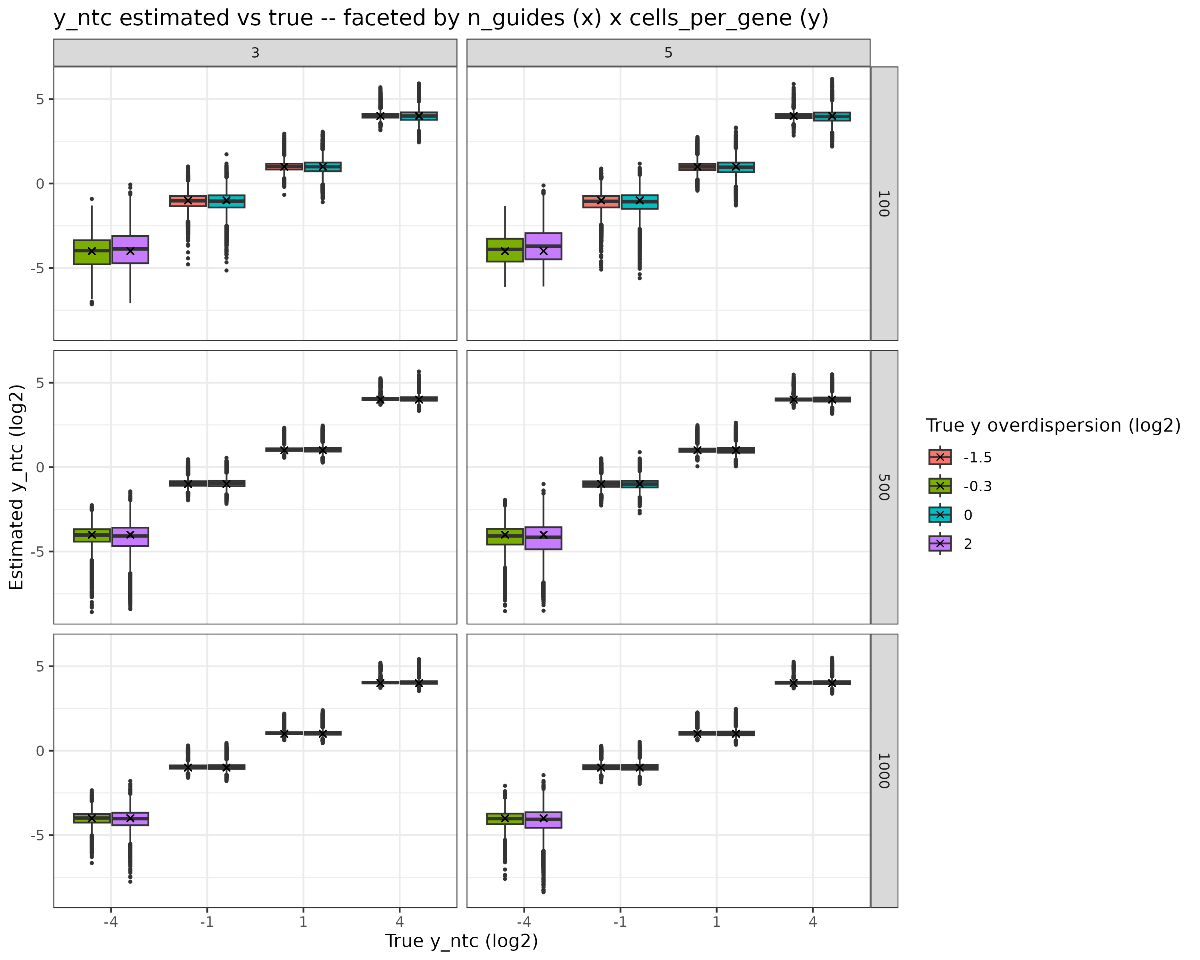

In [23]:
for (shape in guide_shapes) {
  save_plot(make_yntc_boxplot(trans_eval[guide_shape == shape], "cells_per_gene", "n_guides",
                               paste0("faceted by n_guides (x) x cells_per_gene (y), shape=", shape)),
            paste0("3c_yntc_est_vs_true_guides_cells_", shape))
}

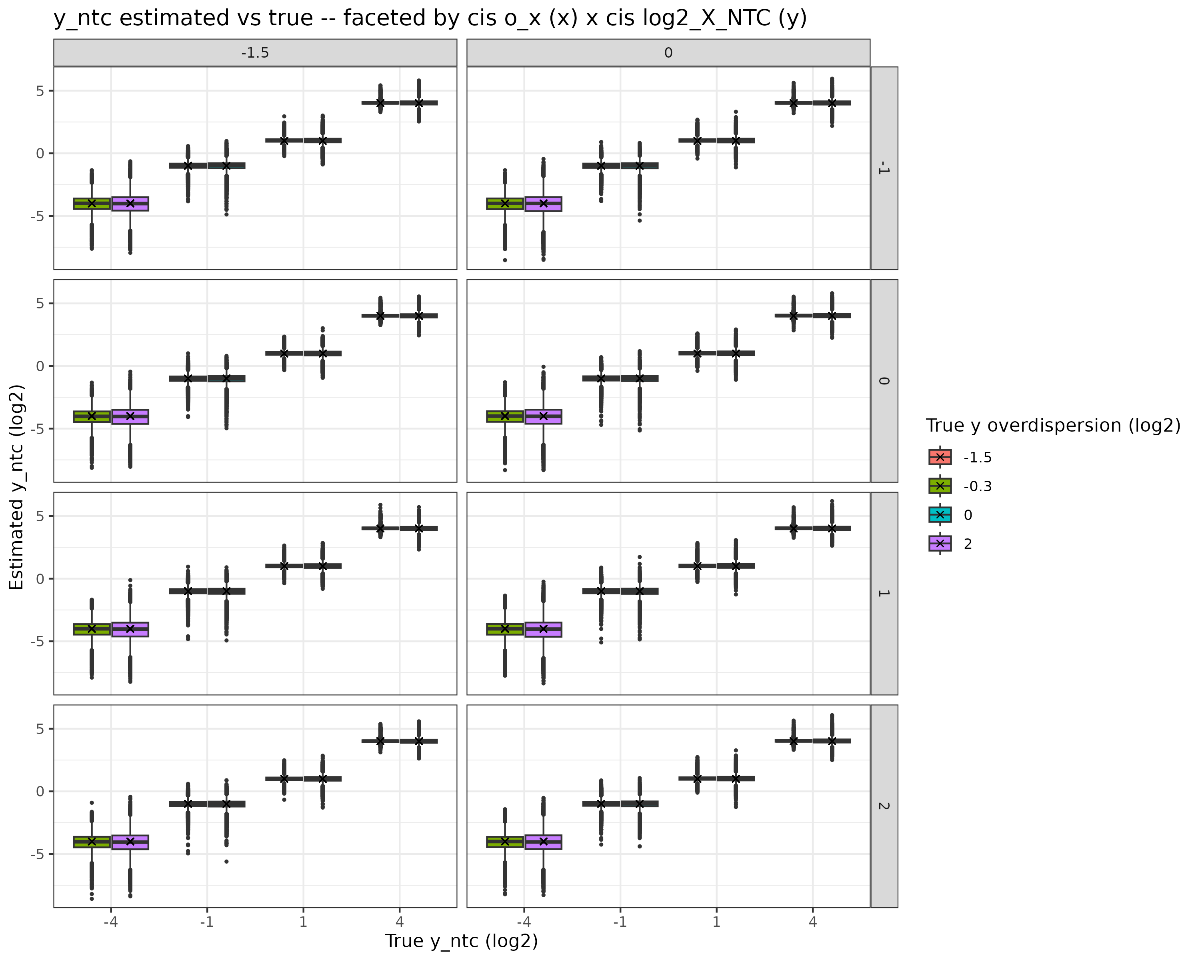

In [24]:
for (shape in guide_shapes) {
  save_plot(make_yntc_boxplot(trans_eval[guide_shape == shape], "log2_X_NTC", "log2_o_x",
                               paste0("faceted by cis o_x (x) x cis log2_X_NTC (y), shape=", shape)),
            paste0("3c_yntc_est_vs_true_cis_ox_xntc_", shape))
}

### 3d. Full log2FC

Boxplot, same binned-`prop_log2FC_observed` x-axis and true-value marker convention as
3a.

In [25]:
sh_fc <- trans_eval[effect_type == "single_hill" & classification == "single_positive" &
                       !is.na(prop_bin) & !is.na(full_log2fc_median)]

make_fulllog2fc_boxplot <- function(dt, facet_rows, facet_cols, title_suffix) {
  ggplot(dt, aes(x = prop_bin, y = full_log2fc_median, fill = factor(full_log2FC_true))) +
    geom_boxplot(outlier.size = 0.5, position = position_dodge(width = 0.8)) +
    geom_point(aes(y = full_log2FC_true), shape = 4, position = position_dodge(width = 0.8),
               color = "black", size = 1.5) +
    facet_grid(reformulate(facet_cols, facet_rows)) +
    labs(x = "Prop. full log2FC observed (binned)", y = "Estimated full log2FC",
         fill = "True full log2FC",
         title = paste("full log2FC estimated vs true --", title_suffix)) +
    theme_bw() + theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

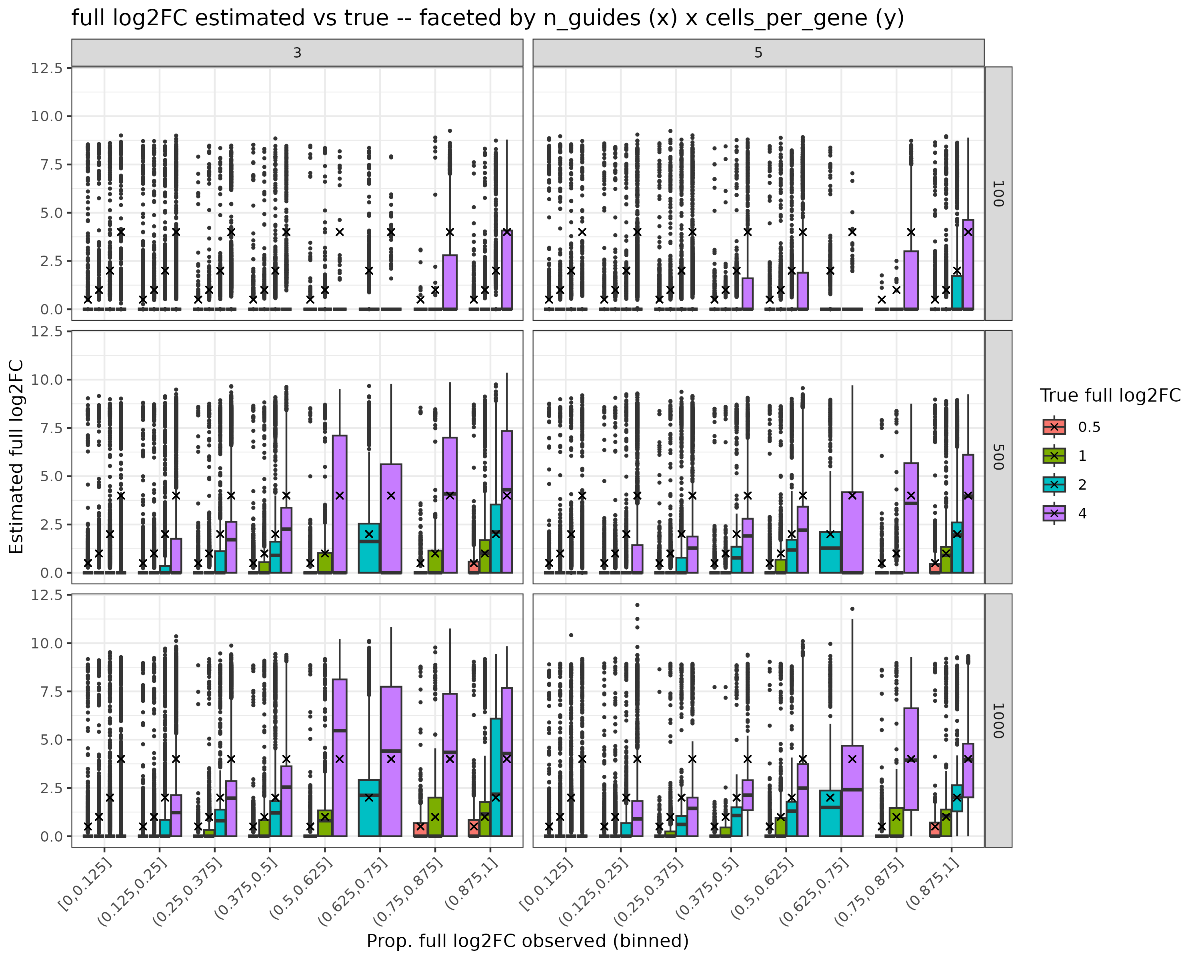

In [26]:
for (shape in guide_shapes) {
  save_plot(make_fulllog2fc_boxplot(sh_fc[guide_shape == shape], "cells_per_gene", "n_guides",
                                     paste0("faceted by n_guides (x) x cells_per_gene (y), shape=", shape)),
            paste0("3d_fulllog2fc_est_vs_true_guides_cells_", shape))
}

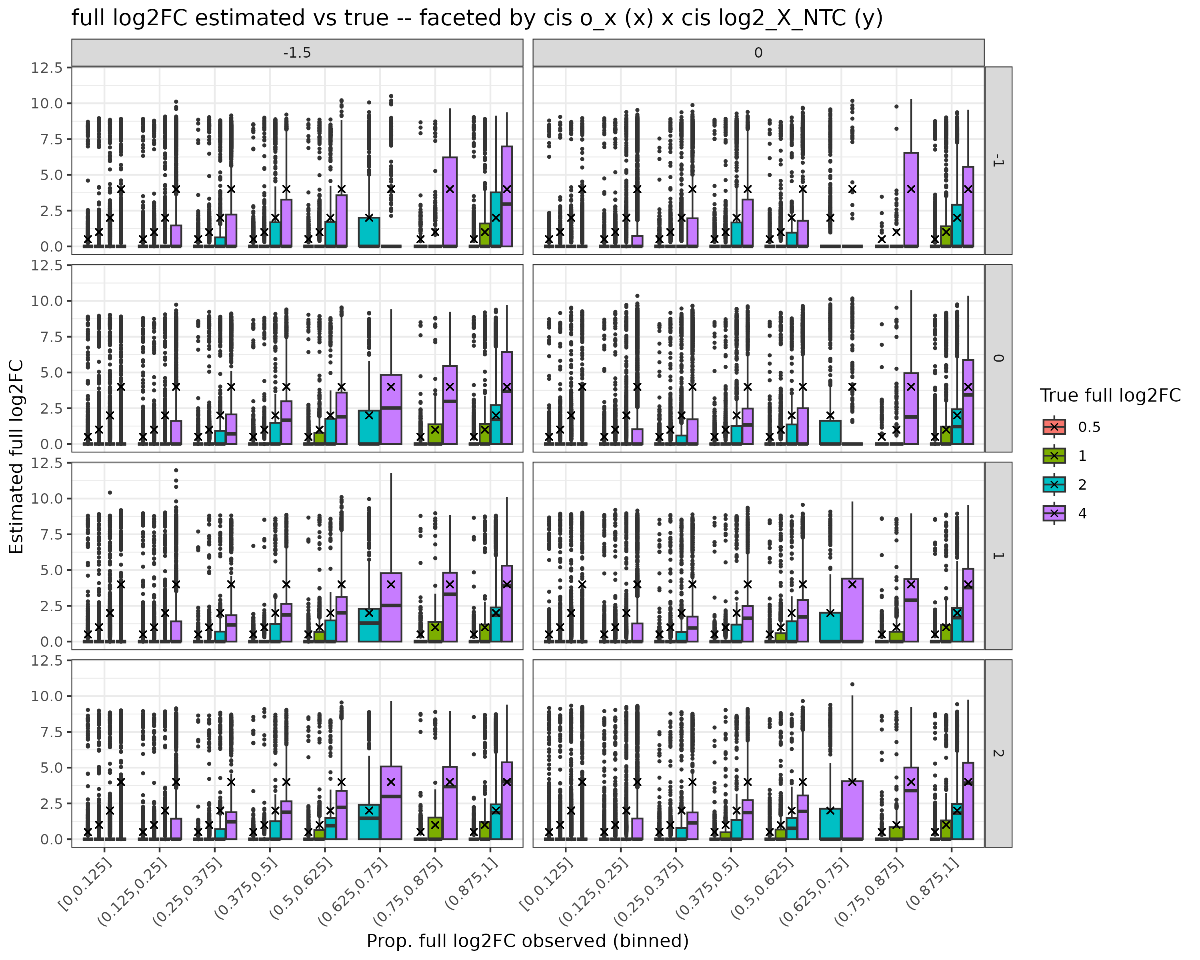

In [27]:
for (shape in guide_shapes) {
  save_plot(make_fulllog2fc_boxplot(sh_fc[guide_shape == shape], "log2_X_NTC", "log2_o_x",
                                     paste0("faceted by cis o_x (x) x cis log2_X_NTC (y), shape=", shape)),
            paste0("3d_fulllog2fc_est_vs_true_cis_ox_xntc_", shape))
}

## 4. fit_cis accuracy: MSE of log2(x_true)

One figure per `guide_shape`, sharing the same x-axis range/category order
(`cells_per_gene` factor levels fixed globally, so a guide_shape missing data at some
cell count shows an empty gap rather than a compressed axis -- keeps the three figures
visually comparable). Note the grid has 4 `log2_X_NTC` levels (-1/0/1/2), giving 4
facet rows, not 3.

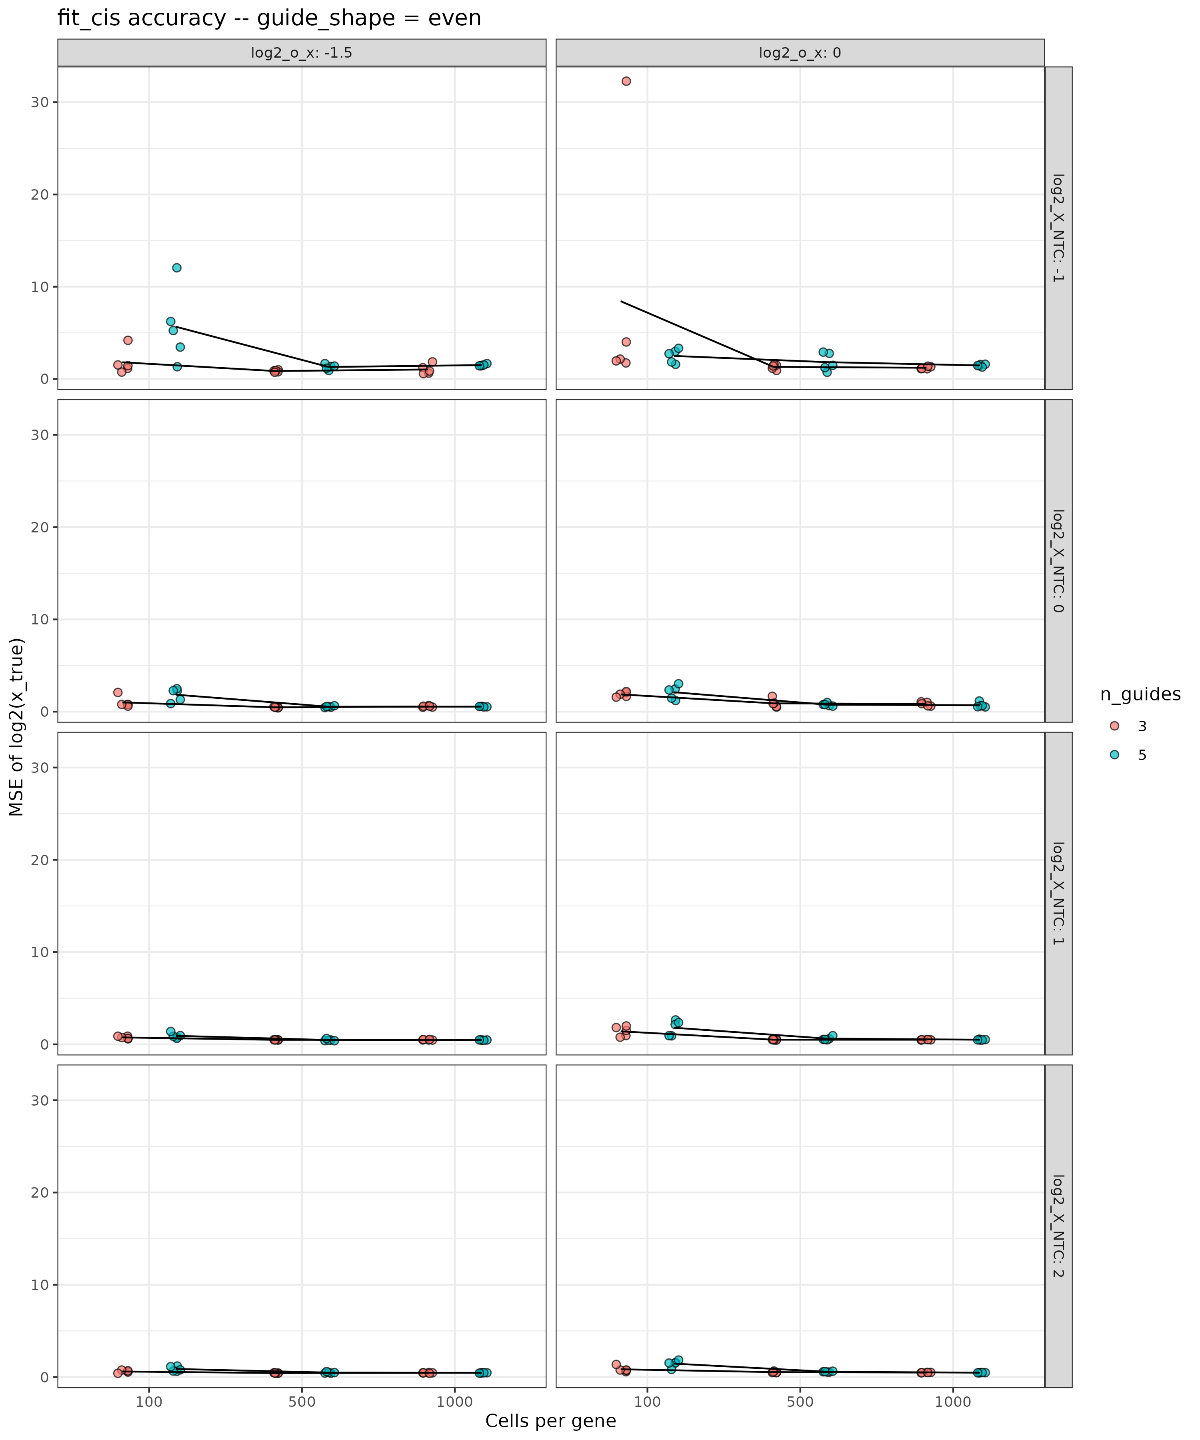

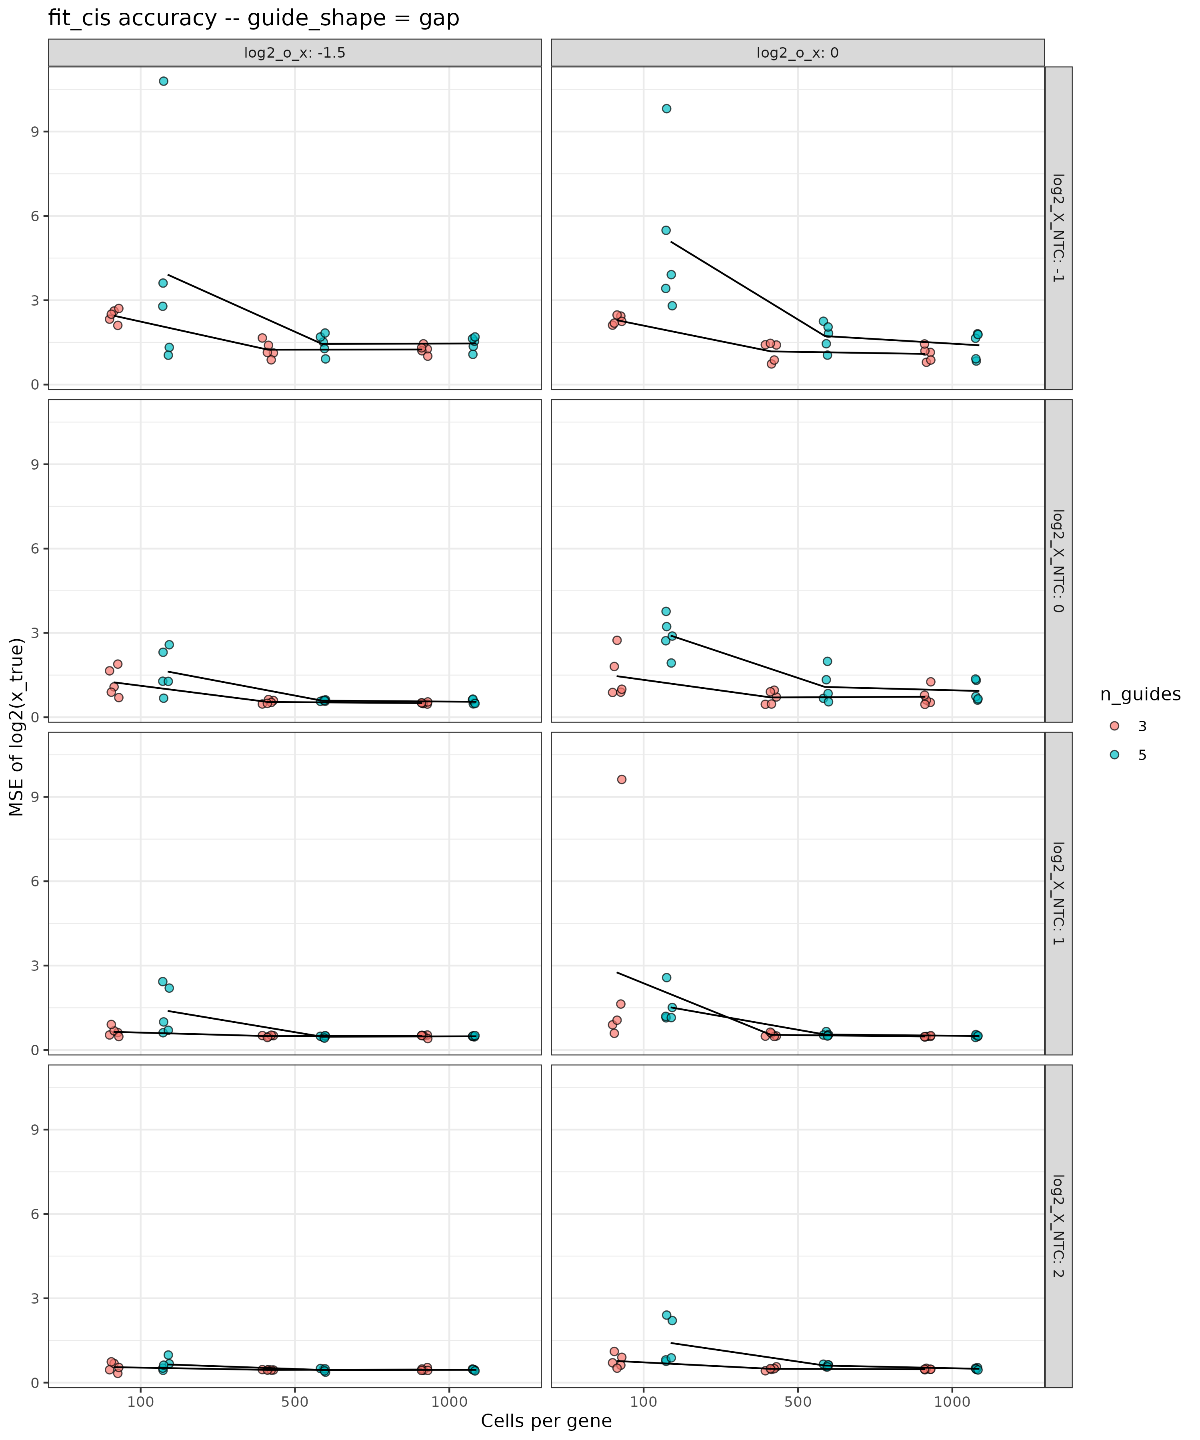

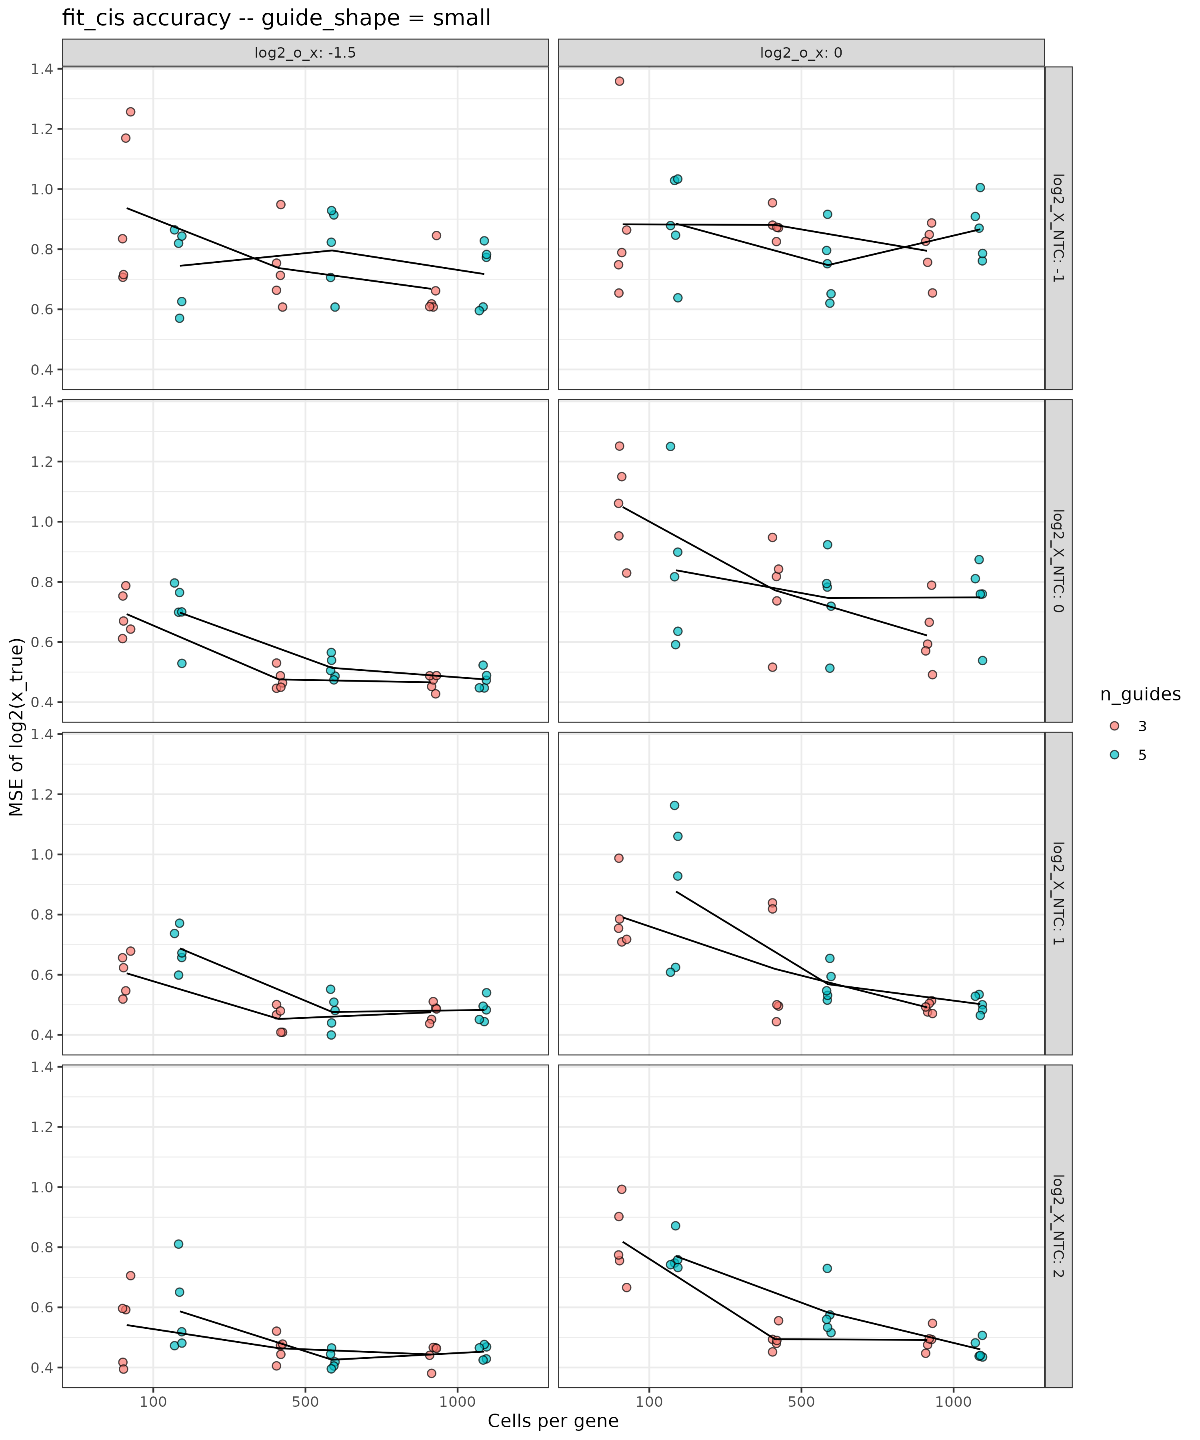

In [28]:
cis_plot_data <- cis_eval[!is.na(mse_log2_x_true)]
cells_levels <- sort(unique(cis_plot_data$cells_per_gene))

for (shape in unique(cis_plot_data$guide_shape)) {
  d <- cis_plot_data[guide_shape == shape]
  p <- ggplot(d, aes(x = factor(cells_per_gene, levels = cells_levels), y = mse_log2_x_true,
                      fill = factor(n_guides))) +
    geom_point(position = position_jitterdodge(jitter.width = 0.15, dodge.width = 0.7),
               shape = 21, size = 2, alpha = 0.7) +
    stat_summary(aes(group = factor(n_guides)), fun = mean, geom = "line",
                 position = position_dodge(width = 0.7), color = "black") +
    scale_x_discrete(drop = FALSE) +
    facet_grid(log2_X_NTC ~ log2_o_x, labeller = label_both) +
    labs(x = "Cells per gene", y = "MSE of log2(x_true)", fill = "n_guides",
         title = sprintf("fit_cis accuracy -- guide_shape = %s", shape)) +
    theme_bw()
  save_plot(p, sprintf("4_cis_mse_%s", shape), height = 12)
}